# Havlicek Benchmark

Havlicek dataset has to yield:
- 0.5 accuracy in classical kernel $\rightarrow$ done
- 1.0 accuracy in quantum kernel

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from config.config import *
from config.experiments import ExperimentConfig
from src.data.preprocessing import preprocess_synthetic
from src.data.saving import svm_exists, load_parameter_train
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.data.synthetic import *
from src.utils.visuals import *
from src.optimization.classical_base import classical_benchmark

RESULTS_DIR = 'Results/Havlicek Benchmark'

## 0. Classical Performance

In [ ]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_classical = []
errs_classical = []
for delta in deltas:
    accs = []
    for seed in range(10):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classical.append(np.mean(accs))
    errs_classical.append(np.std(accs))

data = {'deltas': deltas, 'accuracies_classical': accuracies_classical, 'errs_classical': errs_classical}
df = pd.DataFrame(data)
df.to_csv('Results/Havlicek Benchmark/ClassicalPerformance.csv', index=False)

In [3]:
# open the csv file and plot the results
df = pd.read_csv('Results/Havlicek Benchmark/ClassicalPerformance.csv')
deltas, accuracies_classical, errs_classical = df['deltas'], df['accuracies_classical'], df['errs_classical']

In [ ]:
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical kernel', color='tab:orange', fmt='o')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

## 1. Original Kernel

- Add rescaling to preprocess

In [ ]:
def preprocess_synthetic_new(X, y, tts_seed=TTS_SEED):
    # Split train-test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=tts_seed, stratify=y)

    # Scale features to [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

In [ ]:
delta = 0.5
accuracies_qo = []

config = ExperimentConfig(
    name = f'{RESULTS_DIR}/optuna 100 d{delta}',
    optimizer = 'optuna',
    variant = 'kta',
    subset_method = 'none',
    optimizer_kwargs = {'n_trials': 100},
)
for seed in range(9):
    config.name = f'{RESULTS_DIR}/optuna 100 d{delta} s{seed}'
    X, y = Havlicek_synthetic_dataset(seed=seed, delta=delta)
    X_train, X_test, y_train, y_test = preprocess_synthetic_new(X, y, N_QUBITS)
    
    trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    accuracies_qo.append(results['accuracy'])
    
    unique, counts = np.unique(results['y_pred'], return_counts=True)
    print(f"delta= {delta} seed={seed}: acc={results['accuracy']:.3f}, predicted counts={dict(zip(unique, counts))}")

In [ ]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
for n in range(9):
    plt.scatter(delta, accuracies_qo[n], color='tab:blue', alpha=0.5, label='Quantum kernel' if n==0 else None)
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical kernel', color='tab:orange', fmt='o')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

## 2. Kernel with phases

Now the candidate has `N_LAYERS` worth of rotation gates after a stage of entangling. The new candidate:
- Reuses `OptunaGene`class
- 

In [ ]:
import numpy as np
import optuna
import pennylane as qml
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import rbf_kernel

from config.config import N_QUBITS, N_LAYERS, N_TRIALS
from config.experiments import ExperimentConfig
from src.circuit.candidates import Candidate
from src.circuit.genes import OptunaGene
from src.kernel.metrics import geometric_difference
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.data.saving import (
    candidate_exists, load_parameter_train, save_parameter_train,
    svm_exists, load_svm_results, save_svm_results,
)


# ── Candidate + circuit + kernel ─────────────────────────────────────────

class HavlicekCandidate(Candidate):
    def __init__(self, n_qubits: int, n_layers: int, gates: list, angles: list):
        super().__init__(n_qubits, n_layers)
        for gate, angle in zip(gates, angles):
            self.genes.append(OptunaGene(gate, angle))


def quantum_kernel_matrix_phases(candidate, X1, X2=None):

    def build_circuit(x):
        gene_idx = 0

        # entangling phase (non-parametrized)
        for qubit in range(candidate.n_qubits):
            qml.Hadamard(wires=qubit)
        for qubit in range(candidate.n_qubits - 1):
            qml.CNOT(wires=[qubit, qubit + 1])

        # rotation phase (parametrized)
        for layer in range(candidate.n_layers):
            for qubit in range(candidate.n_qubits):
                gene = candidate.get_ith_gene(gene_idx)
                info = gene.get_gene_info()
                gate, angle = info['gate'], info['angle']

                if gate == 'RX':
                    qml.RX(angle * x[qubit], wires=qubit)
                elif gate == 'RY':
                    qml.RY(angle * x[qubit], wires=qubit)
                elif gate == 'RZ':
                    qml.RZ(angle * x[qubit], wires=qubit)
                elif gate == 'I':
                    pass
                gene_idx += 1

    dev = qml.device('default.qubit', wires=candidate.n_qubits)

    @qml.qnode(dev)
    def quantum_kernel_circuit(x1, x2):
        build_circuit(x1)
        qml.adjoint(build_circuit)(x2)  # type: ignore
        return qml.probs(wires=range(candidate.n_qubits))

    def quantum_kernel(x1, x2):
        return float(quantum_kernel_circuit(x1, x2)[0])

    if X2 is None:
        N = len(X1)
        K = np.zeros((N, N))
        for i in range(N):
            for j in range(i, N):
                K[i, j] = K[j, i] = quantum_kernel(X1[i], X1[j])
        return K

    N1, N2 = len(X1), len(X2)
    K = np.zeros((N1, N2))
    for i in range(N1):
        for j in range(N2):
            K[i, j] = quantum_kernel(X1[i], X2[j])
    return K


# ── Objective + training ─────────────────────────────────────────────────

def objective_optuna_generator_RD_phases(X):
    gamma = 1.0 / (N_QUBITS * X.var())
    K_classical = rbf_kernel(X, gamma=gamma)

    def objective(trial):
        n_genes = N_LAYERS * N_QUBITS
        gates  = [trial.suggest_categorical(f"gate_{i}", ["RX", "RY", "RZ", "I"]) for i in range(n_genes)]
        angles = [trial.suggest_float(f"angle_{i}", 0, 2 * np.pi) for i in range(n_genes)]

        candidate = HavlicekCandidate(N_QUBITS, N_LAYERS, gates, angles)
        K_quantum = quantum_kernel_matrix_phases(candidate, X)
        return geometric_difference(K_classical, K_quantum)

    return objective

from src.kernel.metrics import kernel_target_alignment

def objective_optuna_KTA_generator_phases(X, y):
    def objective(trial):
        n_genes = N_LAYERS * N_QUBITS
        gates  = [trial.suggest_categorical(f"gate_{i}", ["RX", "RY", "RZ", "I"]) for i in range(n_genes)]
        angles = [trial.suggest_float(f"angle_{i}", 0, 2 * np.pi) for i in range(n_genes)]

        candidate = HavlicekCandidate(N_QUBITS, N_LAYERS, gates, angles)
        K_quantum = quantum_kernel_matrix_phases(candidate, X)
        return kernel_target_alignment(K_quantum, y)

    return objective


def train_candidate_optuna_RD_phases(
    name, X_train, y_train, n_trials=N_TRIALS, n_qubits=N_QUBITS, n_layers=N_LAYERS
):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_optuna_generator_RD_phases(X_train), n_trials=n_trials)

    n_genes = n_layers * n_qubits
    best_gates  = [study.best_params[f"gate_{i}"] for i in range(n_genes)]
    best_angles = [study.best_params[f"angle_{i}"] for i in range(n_genes)]
    best_candidate = HavlicekCandidate(n_qubits, n_layers, best_gates, best_angles)

    K_quantum_best = quantum_kernel_matrix_phases(best_candidate, X_train)
    K_classical = rbf_kernel(X_train, gamma=1.0 / (n_qubits * X_train.var()))

    save_parameter_train(name, best_candidate, study.best_value, K_quantum_best, K_classical, X_train, y_train)
    return study.best_value, best_candidate, K_quantum_best, K_classical

def train_candidate_optuna_KTA_phases(
    name, X_train, y_train, n_trials=N_TRIALS, n_qubits=N_QUBITS, n_layers=N_LAYERS
):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_optuna_KTA_generator_phases(X_train, y_train), n_trials=n_trials)

    n_genes = n_layers * n_qubits
    best_gates  = [study.best_params[f"gate_{i}"] for i in range(n_genes)]
    best_angles = [study.best_params[f"angle_{i}"] for i in range(n_genes)]
    best_candidate = HavlicekCandidate(n_qubits, n_layers, best_gates, best_angles)

    K_quantum_best = quantum_kernel_matrix_phases(best_candidate, X_train)
    K_classical = rbf_kernel(X_train, gamma=1.0 / (n_qubits * X_train.var()))

    save_parameter_train(name, best_candidate, study.best_value, K_quantum_best, K_classical, X_train, y_train)
    return study.best_value, best_candidate, K_quantum_best, K_classical


# ── ExperimentConfig-style pipeline ──────────────────────────────────────

_SUBSET_METHODS = {
    'random':             subset_random,
    'nystrom_global':     subset_nystrom_global,
    'nystrom_stratified': subset_nystrom_stratified,
    'none':               None,
}
_TRAIN_FUNCTIONS = {
    'geometric': train_candidate_optuna_RD_phases,
    'kta':       train_candidate_optuna_KTA_phases,
}

def get_candidate_phases(config: ExperimentConfig, X_train, y_train):
    load_name = config.load_from or config.name

    if candidate_exists(load_name):
        print(f"Loading cached candidate for '{load_name}'")
        data = load_parameter_train(load_name)
        return data['candidate'], data['K_quantum'], data['K_classical'], data['X_subset'], data['y_subset']

    if _SUBSET_METHODS[config.subset_method] is None:
        X_sub, y_sub = X_train, y_train
    else:
        subset_fn = _SUBSET_METHODS[config.subset_method]
        _, X_sub, y_sub = subset_fn(X_train, y_train, **config.subset_kwargs)

    train_fn = _TRAIN_FUNCTIONS[config.variant]
    _, candidate, K_q, K_c = train_fn(config.name, X_sub, y_sub, **config.optimizer_kwargs)
    return candidate, K_q, K_c, X_sub, y_sub


def get_svm_results_phases(config: ExperimentConfig, K_train, y_train, K_test, y_test, c_range=None, cv=5):
    if svm_exists(config.name):
        print(f"Loading cached SVM results for '{config.name}'")
        return load_svm_results(config.name)

    if c_range is None:
        c_range = {'C': [0.1, 1, 10, 100, 1000]}

    grid = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'), c_range, cv=cv, scoring='balanced_accuracy',
    )
    grid.fit(K_train, y_train)
    y_pred = grid.best_estimator_.predict(K_test)

    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'best_C': grid.best_params_['C'],
        'best_cv_accuracy': grid.best_score_,
        'y_pred': y_pred, 'y_test': y_test, 'K_test': K_test,
        'report': classification_report(y_test, y_pred, zero_division=0),
    }
    save_svm_results(config.name, results)
    return results

Call the experiments

In [ ]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_qphases, errs_qphases = [], []
for delta in deltas:
    accs = []
    for seed in range(3):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

        config = ExperimentConfig(
            name=f'{RESULTS_DIR}/optuna kta delta{delta:.2f}_seed{seed}',
            optimizer='optuna',
            variant='kta',
            subset_method='none',
            optimizer_kwargs={'n_trials': 100},
        )

        candidate, K_train, K_classical, X_sub, y_sub = get_candidate_phases(config, X_train, y_train)

        K_test = None
        if not svm_exists(config.name):
            print(f"Computing cross-kernel (delta={delta:.2f}, seed={seed})…")
            K_test = quantum_kernel_matrix_phases(candidate, X_test, X_sub)

        results = get_svm_results_phases(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])

    accuracies_qphases.append(np.mean(accs))
    errs_qphases.append(np.std(accs))

In [ ]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.scatter(deltas, accuracies_qphases, color='tab:green', alpha=0.5, label='Quantum Phases (kta)')
plt.scatter(deltas, accuracies_classical, color='tab:orange', alpha=0.5, label='Classical Kernel')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random Guess')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

## 3. Kernel with phases + entangling

In [ ]:
deltas = np.linspace(0.1, 0.6, 5)
accuracies_qcross, errs_qcross = [], []
for delta in deltas:
    accs = []
    for seed in range(3):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

        config = ExperimentConfig(
            name=f'{RESULTS_DIR}/optuna kta_cross delta{delta:.2f}_seed{seed}',
            optimizer='optuna',
            variant='kta_cross',
            subset_method='none',
            optimizer_kwargs={'n_trials': 100},
        )

        candidate, K_train, K_classical, X_sub, y_sub = get_candidate_havlicek(config, X_train, y_train)

        K_test = None
        if not svm_exists(config.name):
            print(f"Computing cross-kernel (delta={delta:.2f}, seed={seed})…")
            K_test = _KERNEL_FUNCTIONS[config.variant](candidate, X_test, X_sub)

        results = get_svm_results_havlicek(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
        print(f'Accuracy of delta {delta} | seed {seed}: ', results['accuracy'])

    accuracies_qcross.append(np.mean(accs))
    errs_qcross.append(np.std(accs))

In [ ]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.errorbar(deltas, accuracies_qcross, yerr=errs_qcross, label='Quantum Cross-feature (kta_cross)', color='tab:green', fmt='o')
deltas = np.linspace(0.1, 0.6, 10)
plt.errorbar(deltas, accuracies_classical, yerr=errs_classical, label='Classical kernel', color='tab:orange', fmt='o')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

## 4. Forced Kernel

In [12]:
def quantum_kernel_matrix_forcedhavlicek(X1, X2 = None):

    def build_circuit(x):
        """Encode data in quantum state. Havlicek et al."""
        # superposition
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(2 * x[i], wires=i)

        # encoding information
        for i in range(n_qubits):
            for j in range(i+1, n_qubits):
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[j]), wires=j)
                qml.CNOT(wires=[i, j])

    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev)
    def quantum_kernel_circuit(x1, x2):
        build_circuit(x1)
        qml.adjoint(build_circuit)(x2) # pyright: ignore[reportCallIssue]
        return qml.probs(wires=range(n_qubits))

    def quantum_kernel(x1, x2):
        return float(quantum_kernel_circuit(x1, x2)[0])

    if X2 is None:
        N = len(X1)
        K_quantum = np.zeros((N, N))

        for i in range(N):
            for j in range(i, N):
                value = quantum_kernel(X1[i], X1[j])
                K_quantum [i,j] = value
                K_quantum [j,i] = value
    else:
        # former 'quantum_kernel_matrix_cross()'
        N1, N2 = len(X1), len(X2)
        K_quantum = np.zeros((N1, N2))
        for i in range(N1):
            for j in range(N2):
                K_quantum[i, j] = quantum_kernel(X1[i], X2[j])
    return K_quantum
        

## 5. Kernel with Havlicek

New automated kernel; now:
1. Entangling phase
2. Rotation phase with CNOT + R + CNOT. Feature encoded here

In [4]:
import numpy as np
import optuna
import pennylane as qml
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import rbf_kernel

from config.config import N_QUBITS, N_LAYERS, N_TRIALS
from config.experiments import ExperimentConfig
from src.circuit.candidates import OptunaCandidate
from src.circuit.genes import OptunaGene
from src.kernel.metrics import geometric_difference
from src.data.saving import (
    candidate_exists, load_parameter_train, save_parameter_train,
    svm_exists, load_svm_results, save_svm_results,
)
from src.kernel.metrics import kernel_target_alignment
import itertools

In [21]:
# HERE, THE ANGLES ARE PARAMETRIZED
# COPY: fix angles so they are sampled from smaller values
def n_genes_havlicek(n_qubits, n_layers):
    n_pairs = n_qubits * (n_qubits - 1) // 2
    return n_layers * n_pairs


def quantum_kernel_matrix_havlicek(candidate, X1, X2=None):

    def build_circuit(x):
        gene_idx = 0

        # entangling phase (non-parametrized)
        for qubit in range(candidate.n_qubits):
            qml.Hadamard(wires=qubit)
            qml.RZ(2 * x[qubit], wires=qubit)
            
        # rotation phase (parametrized)
        # NOTE: now all qubits are entangled
        for layer in range(candidate.n_layers):
            for i, j in itertools.combinations(range(candidate.n_qubits), 2):
                gene = candidate.get_ith_gene(gene_idx)
                info = gene.get_gene_info()
                gate, angle = info['gate'], info['angle']

                if gate in ('RX', 'RY', 'RZ'):
                    qml.CNOT(wires=[i, j])
                    getattr(qml, gate)(angle * (np.pi - x[i]) * (np.pi - x[j]), wires=j)
                    qml.CNOT(wires=[i, j])
                    
                gene_idx += 1

    dev = qml.device("default.qubit", wires=candidate.n_qubits)
    @qml.qnode(dev)
    def quantum_kernel_circuit(x1, x2):
        build_circuit(x1)
        qml.adjoint(build_circuit)(x2) # pyright: ignore[reportCallIssue]
        return qml.probs(wires=range(candidate.n_qubits))

    def quantum_kernel(x1, x2):
        return float(quantum_kernel_circuit(x1, x2)[0])

    if X2 is None:
        N = len(X1)
        K_quantum = np.zeros((N, N))
        for i in range(N):
            for j in range(i, N):
                value = quantum_kernel(X1[i], X1[j])
                K_quantum[i, j] = value
                K_quantum[j, i] = value
    else:
        N1, N2 = len(X1), len(X2)
        K_quantum = np.zeros((N1, N2))
        for i in range(N1):
            for j in range(N2):
                K_quantum[i, j] = quantum_kernel(X1[i], X2[j])
    return K_quantum

# ── Objective + training ─────────────────────────────────────────────────
# TODO: faltan funciones con geometric difference
def objective_optuna_generator_KTA_havlicek(X, y, n_qubits, n_layers):
    def objective(trial):
        n_genes = n_genes_havlicek(n_qubits, n_layers)
        gates = [trial.suggest_categorical(f"gate_{i}", ["RX", "RY", "RZ", "I"]) for i in range(n_genes)]
        angles = [trial.suggest_float(f"angle_{i}", 0, 0.5) for i in range(n_genes)]

        candidate = OptunaCandidate(n_qubits, n_layers, gates, angles)
        K_quantum = quantum_kernel_matrix_havlicek(candidate, X)
        return kernel_target_alignment(K_quantum, y)
    return objective

def train_candidate_optuna_KTA_havlicek(
    name, X_train, y_train, n_trials=N_TRIALS, n_qubits=N_QUBITS, n_layers=N_LAYERS
):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_optuna_generator_KTA_havlicek(X_train, y_train, n_qubits, n_layers), n_trials=n_trials)

    n_genes = n_genes_havlicek(n_qubits, n_layers)
    best_gates  = [study.best_params[f"gate_{i}"] for i in range(n_genes)]
    best_angles = [study.best_params[f"angle_{i}"] for i in range(n_genes)]
    best_candidate = OptunaCandidate(n_qubits, n_layers, best_gates, best_angles)

    K_quantum_best = quantum_kernel_matrix_havlicek(best_candidate, X_train)
    K_classical = rbf_kernel(X_train, gamma=1.0/(n_qubits * X_train.var()))

    save_parameter_train(name, best_candidate, study.best_value, K_quantum_best, K_classical, X_train, y_train)
    return study.best_value, best_candidate, K_quantum_best, K_classical

# ── ExperimentConfig pipeline ───────────────────────────────────────────
_SUBSET_METHODS = {
    # 'random':             subset_random,
    # 'nystrom_global':     subset_nystrom_global,
    # 'nystrom_stratified': subset_nystrom_stratified,
    'none':               None,
}
_TRAIN_FUNCTIONS = {
    #'geometric': train_candidate_optuna_RD_havlicek,
    'kta':       train_candidate_optuna_KTA_havlicek,
}
def get_candidate_havlicek(config:ExperimentConfig, X_train, y_train):
    load_name = config.load_from or config.name

    if candidate_exists(load_name):
        print(f"Loading cached candidate for '{load_name}'")
        data = load_parameter_train(load_name)
        return data['candidate'], data['K_quantum'], data['K_classical'], data['X_subset'], data['y_subset']
    
    if _SUBSET_METHODS[config.subset_method] is None:
        X_sub, y_sub = X_train, y_train
    else:
        subset_fn = _SUBSET_METHODS[config.subset_method]
        _, X_sub, y_sub = subset_fn(X_train, y_train, **config.subset_kwargs)
    
    train_fn = _TRAIN_FUNCTIONS[config.variant]
    _, candidate, K_q, K_c = train_fn(config.name, X_sub, y_sub, **config.optimizer_kwargs)
    return candidate, K_q, K_c, X_sub, y_sub

def get_svm_results_havlicek(config: ExperimentConfig, K_train, y_train, K_test, y_test, c_range=None, cv=5):
    if svm_exists(config.name):
        print(f"Loading cached SVM results for '{config.name}'")
        return load_svm_results(config.name)

    if c_range is None:
        c_range = {'C': [0.1, 1, 10, 100, 1000]}

    grid = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'), c_range, cv=cv, scoring='balanced_accuracy',
    )
    grid.fit(K_train, y_train)
    y_pred = grid.best_estimator_.predict(K_test)

    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'best_C': grid.best_params_['C'],
        'best_cv_accuracy': grid.best_score_,
        'y_pred': y_pred, 'y_test': y_test, 'K_test': K_test,
        'report': classification_report(y_test, y_pred, zero_division=0),
    }
    save_svm_results(config.name, results)
    return results

Call the experiments

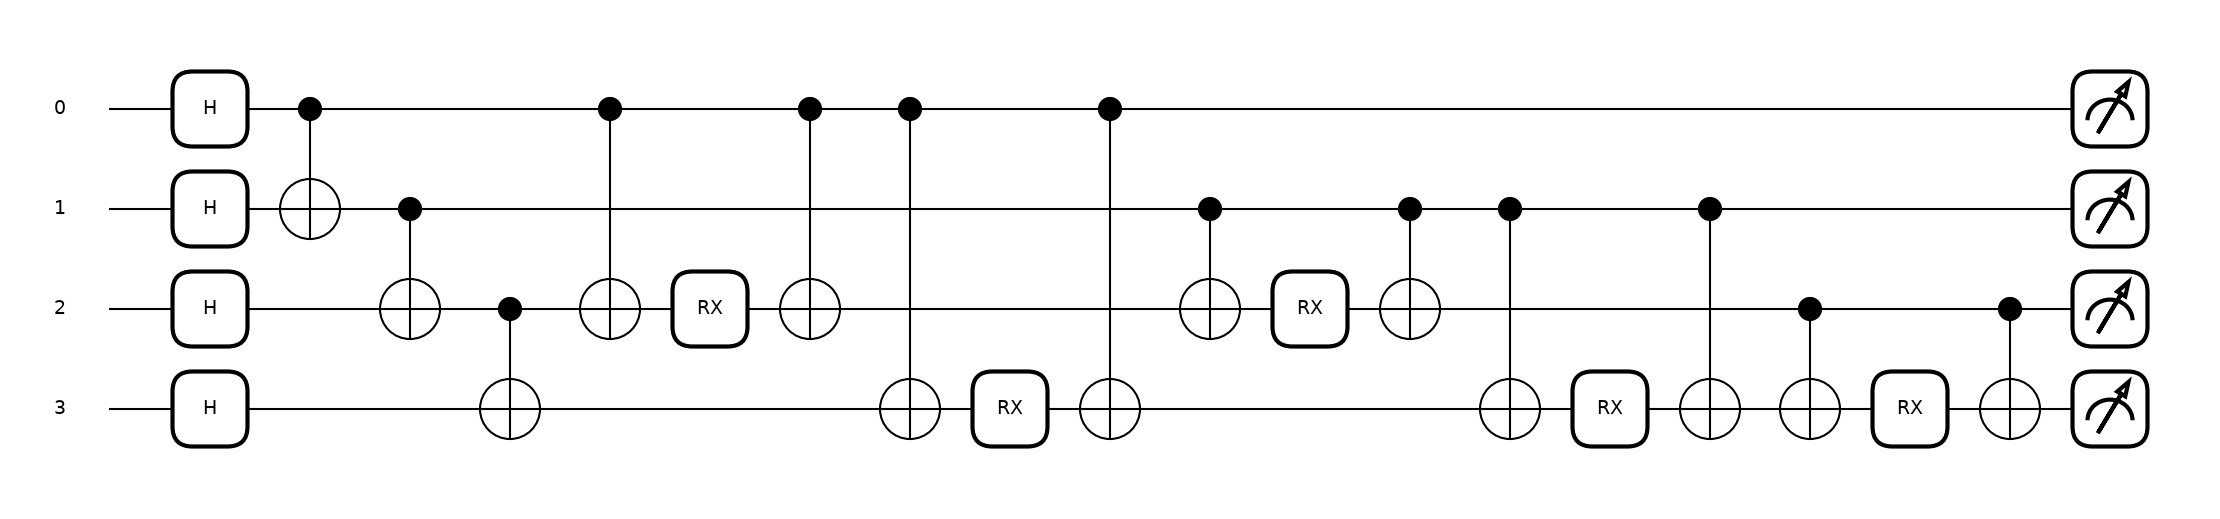

In [11]:
# example of random candidate
GATES = ("RX", "RY", "RZ", "I")
N_QUBITS, N_LAYERS = 4, 1
N_PAIRS = N_QUBITS * (N_QUBITS - 1) // 2
n_genes = N_LAYERS * N_PAIRS

rng = np.random.default_rng()
gates = list(rng.choice(GATES, size=n_genes))
angles = list(rng.uniform(0, 2 * np.pi, size=n_genes))
random_candidate = OptunaCandidate(N_QUBITS, N_LAYERS, gates, angles)

x = rng.uniform(0, 2 * np.pi, size=N_QUBITS)

# print circuit
def build_circuit_havlicek(candidate, x):
    gene_idx = 0

    # entangling phase (non-parametrized)
    for qubit in range(candidate.n_qubits):
        qml.Hadamard(wires=qubit)
    for qubit in range(candidate.n_qubits - 1):
        qml.CNOT(wires=[qubit, qubit + 1])

    # rotation phase (parametrized) — all-pairs
    for layer in range(candidate.n_layers):
        for i, j in itertools.combinations(range(candidate.n_qubits), 2):
            gene = candidate.get_ith_gene(gene_idx)
            info = gene.get_gene_info()
            gate, angle = info['gate'], info['angle']

            if gate in ('RX', 'RY', 'RZ'):
                qml.CNOT(wires=[i, j])
                getattr(qml, gate)(angle * x[i] * x[j], wires=j)
                qml.CNOT(wires=[i, j])
            # else: 'I', do nothing

            gene_idx += 1

dev = qml.device("default.qubit", wires=N_QUBITS)
@qml.qnode(dev)
def draw_circuit(candidate, x):
    build_circuit_havlicek(candidate, x)
    return qml.probs(wires=range(N_QUBITS))

fig, ax = qml.draw_mpl(draw_circuit)(random_candidate, x)

In [ ]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_havlicek, errs_havlicek = [], []

for delta in [0.5]:
    accs = []
    for seed in range(3):
        X, y = Havlicek_synthetic_dataset(n_per_class=40, delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

        config = ExperimentConfig(
            name=f'Havlicek Benchmark/optuna kta havlicek c 40 d{delta:.2f} s{seed}',
            optimizer='optuna',
            variant='kta',
            subset_method='none',
            optimizer_kwargs={'n_trials': 100, 'n_layers': 1},
        )
        print(f"Training candidate for delta={delta:.2f}, seed={seed}, n_layers={config.optimizer_kwargs['n_layers']}")
        candidate, K_train, K_classical, X_sub, y_sub = get_candidate_havlicek(config, X_train, y_train)

        K_test = None
        if not svm_exists(config.name):
            print(f"Computing cross-kernel (delta={delta:.2f}, seed={seed})…")
            K_test = quantum_kernel_matrix_havlicek(candidate, X_test, X_sub)

        results = get_svm_results_havlicek(config, K_train, y_sub, K_test, y_test)
        accs.append(results['accuracy'])
        print(f'Accuracy of delta {delta} | seed {seed}: ', results['accuracy'])

    accuracies_havlicek.append(np.mean(accs))
    errs_havlicek.append(np.std(accs))

In [ ]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.scatter(deltas, accuracies_classical, color='tab:orange', alpha=0.5, label='Classical Kernel')
plt.scatter(deltas[:len(accuracies_havlicek)], accuracies_havlicek, color='tab:blue', alpha=0.5, label='Havlicek Kernel (kta)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random Guess')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
plt.ylim(0, 1.15)
plt.show()

i'll try to figure out why do we have those shitty results

In [9]:
X, y = Havlicek_synthetic_dataset(n_per_class=40, delta=0.5, seed=0)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y)

# Diagnostic: check kernel concentration
rng = np.random.default_rng(0)
n_qubits, n_layers = N_QUBITS, 1
n_genes = n_genes_havlicek(n_qubits, n_layers)

gates = list(rng.choice(["RX", "RY", "RZ", "I"], size=n_genes))
angles = list(rng.uniform(0, 2 * np.pi, size=n_genes))   # current (wide) bounds
test_candidate = OptunaCandidate(n_qubits, n_layers, gates, angles)

K_quantum = quantum_kernel_matrix_havlicek(test_candidate, X_train)

print("mean:", K_quantum.mean())
print("std: ", K_quantum.std())
print("min/max:", K_quantum.min(), K_quantum.max())

mean: 0.13698357944568776
std:  0.1934469616316056
min/max: 3.210515622520744e-07 0.9999999999999993


In [14]:
K_fixed = quantum_kernel_matrix_forcedhavlicek(X_train)
print("KTA of fixed Havlicek kernel:", kernel_target_alignment(K_fixed, y_train))

KTA of fixed Havlicek kernel: 0.24705858446762893


In [ ]:
ktas = []
for _ in range(20):
    gates = list(rng.choice(["RX","RY","RZ","I"], size=n_genes))
    angles = list(rng.uniform(0, 2*np.pi, size=n_genes))
    cand = OptunaCandidate(n_qubits, n_layers, gates, angles)
    K = quantum_kernel_matrix_havlicek(cand, X_train)
    ktas.append(kernel_target_alignment(K, y_train))

print("random-candidate KTA: mean", np.mean(ktas), "max", np.max(ktas))

random-candidate KTA: mean 0.10520291749151847 max 0.13628264056320874
